# Preprocessing data

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')
import ice

import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
import pathlib
import datetime
from scipy.io import loadmat

In [2]:
# load simulation data
Eb = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_basal_grid.mat")['enthalpy_basal_grid']
Em = loadmat("../data/NGrIS/ensemble_data_pixelated/enthalpy_avg_grid.mat")['enthalpy_avg_grid']
pmp = loadmat("../data/NGrIS/ensemble_data_pixelated/pmp_grid.mat")['pmp_grid']
radar_mask = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_mask.mat")['radar_mask']

Eb = np.array(Eb)
Em = np.array(Em)
pmp = pmp[:, :, np.newaxis]
pmp = np.tile(pmp, (1, 1, Eb.shape[2]))

# convert Em to attenu rate
Tb = ice.enthalpy_to_temperature(Eb, Tpmp = pmp, istorch = False)
Tm = ice.enthalpy_to_temperature(Em, Tpmp = pmp, istorch = False)

# # check for non convergent samples, generate graphs for each sample
# Tb_save_path = "../data/NGrIS/ensemble_data_pixelated/Eb_samples/"
# pathlib.Path(Tb_save_path).mkdir(parents=True, exist_ok=True)
# Tm_save_path = "../data/NGrIS/ensemble_data_pixelated/Em_samples/"
# pathlib.Path(Tm_save_path).mkdir(parents=True, exist_ok=True)

# for i in range(Tb.shape[2]):
#     fig, ax = plt.subplots()
#     im1 = ax.imshow(Tb[:, :, i], vmin = 240, vmax = 273.15)
#     plt.colorbar(im1)
#     ax.set_title(f"Eb sample {i+1}")
#     fig.savefig(f"{Tb_save_path}Tb_{i+1}.png")
#     plt.close(fig)

#     fig, ax = plt.subplots()
#     im2 = ax.imshow(Tm[:, :, i], vmin = 240, vmax = 273.15)
#     plt.colorbar(im2)
#     ax.set_title(f"Em sample {i+1}")
#     fig.savefig(f"{Tm_save_path}Tm_{i+1}.png")
#     plt.close(fig)

# remove samples that did not converge

# convert Tm to attenu rate
attenu = ice.temperature_to_atten_rate_ice(Tm)

non_convergence_idx = np.arange(attenu.shape[2])[np.all(np.isnan(attenu), axis = (0, 1))]
attenu = np.delete(attenu, non_convergence_idx, axis = 2)

transformer_Eb = sklearn.preprocessing.PowerTransformer()
transformer_attenu = sklearn.preprocessing.PowerTransformer()

Eb_standard = transformer_Eb.fit_transform(Eb.reshape(-1, 1))
Eb_standard = Eb_standard.reshape(int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), int(np.sqrt(np.shape(Eb_standard)[0]/Eb.shape[2])), Eb.shape[2])
attenu_fromEm_standard = transformer_attenu.fit_transform(attenu.reshape(-1, 1))
attenu_fromEm_standard = attenu_fromEm_standard.reshape(int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu.shape[2])), int(np.sqrt(np.shape(attenu_fromEm_standard)[0]/attenu.shape[2])), attenu.shape[2])

# filter points not on radar flight path
attenu_fromEm_standard[np.tile(radar_mask[:, :, np.newaxis], (1, 1, attenu_fromEm_standard.shape[2])) != 1] = 0
attenu_fromEm_standard = np.moveaxis(attenu_fromEm_standard, -1, 0)
attenu_fromEm_standard = attenu_fromEm_standard[:, np.newaxis, :, :]
attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
np.savez('attenu_fromEm_standard.npz', attenu_fromEm_standard = attenu_fromEm_standard)
attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

Eb_standard = np.moveaxis(Eb_standard, -1, 0)
Eb_standard = Eb_standard[:, np.newaxis, :, :]
Eb_standard[np.isnan(Eb_standard)] = 0
np.savez('Eb_standard.npz', Eb_standard = Eb_standard)
Eb_standard = torch.tensor(Eb_standard).float()

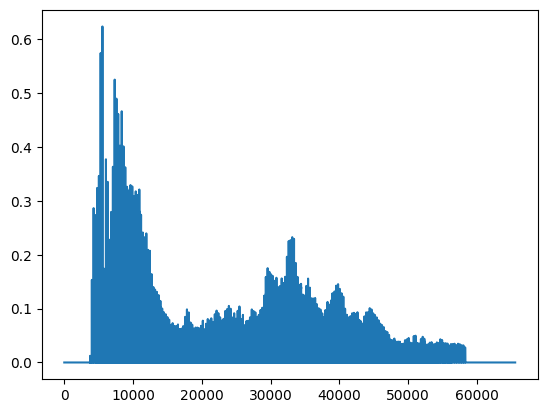

In [3]:
var = np.nanvar(attenu_fromEm_standard, axis = 0)
im1 = plt.plot(var[0, :, :].flatten())

In [4]:
# attenu_shift = -torch.min(attenu_fromEm_standard)
# attenu_scale = 1 / (torch.max(attenu_fromEm_standard) - torch.min(attenu_fromEm_standard))

# Eb_shift = -torch.min(Eb_standard)
# Eb_scale = 1 / (torch.max(Eb_standard) - torch.min(Eb_standard))


# attenu_fromEm_standard = (attenu_fromEm_standard + attenu_shift) * attenu_scale
# Eb_standard = (Eb_standard + Eb_shift) * Eb_scale

In [5]:
# attenu_pca = sklearn.decomposition.PCA(n_components = 32)

# attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

# # train_size = int(0.7 * len(attenu_fromEm_standard))
# # val_size = int((len(attenu_fromEm_standard) - train_size)/2)
# # test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

# # generator = torch.Generator().manual_seed(42)
# # attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

# # torch.save(attenu_fromEm_train_dataset, 'attenu_fromEm_train_dataset.pt')
# # torch.save(attenu_fromEm_val_dataset, 'attenu_fromEm_val_dataset.pt')
# # torch.save(attenu_fromEm_test_dataset, 'attenu_fromEm_test_dataset.pt')

# attenu_pca.fit(attenu_fromEm_dataset[:][0].detach().numpy()[:, 0, :, :].reshape((-1, attenu_fromEm_dataset[:][0].shape[2] ** 2)))

# import joblib

# joblib.dump(attenu_pca, f'attenu_pca{datetime.datetime.now()}.pkl') 

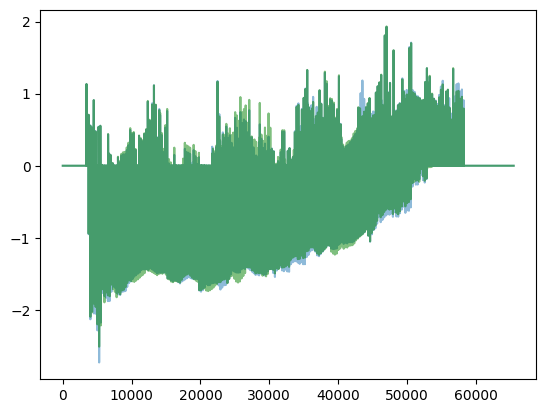

In [ ]:
# attenu_fromEm_test_reconstruct = attenu_pca.inverse_transform(attenu_pca.transform(attenu_fromEm_test_dataset[:][0].detach().numpy()[:, 0, :, :].reshape((-1, attenu_fromEm_test_dataset[:][0].shape[2] ** 2))))
# attenu_fromEm_test_reconstruct = attenu_fromEm_test_reconstruct.reshape((-1, int(np.sqrt(attenu_fromEm_test_reconstruct.shape[1])), int(np.sqrt(attenu_fromEm_test_reconstruct.shape[1]))))

# plt.plot(attenu_fromEm_test_dataset[:][0].detach().numpy()[0, 0, :, :].flatten(), alpha = 0.5)
# plt.plot(attenu_fromEm_test_reconstruct[0, :, :].flatten(), alpha = 0.5, c = 'green')

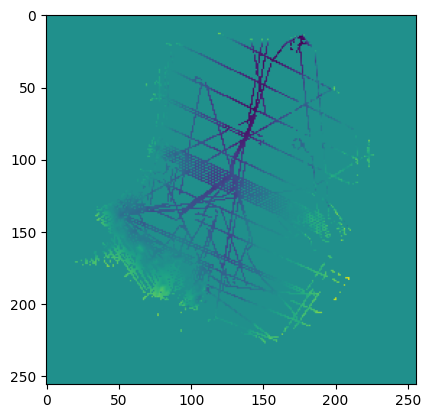

In [6]:
plt.imshow(attenu_fromEm_standard[0, 0, :, :], vmin = -2, vmax = 2)

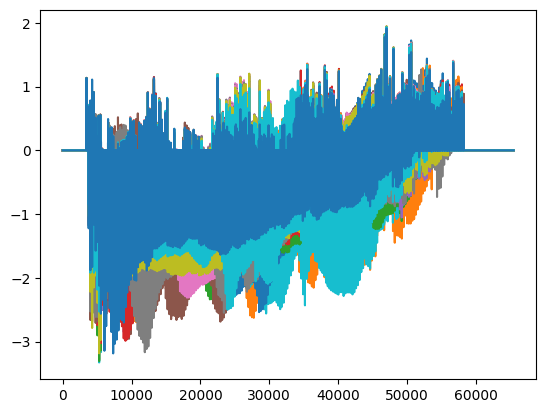

In [7]:
for i in range(0,  len(attenu_fromEm_standard), 10):
    plt.plot(attenu_fromEm_standard[i, 0, :, :].flatten())

In [4]:
# # load attenuation rate data from observation and generate samples assuming normal distribution
# attenu_mean = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_attenu_rate_mean_grid.mat")['radar_attenu_rate_mean_grid']
# attenu_std = loadmat("../data/NGrIS/ensemble_data_pixelated/radar_attenu_rate_uncertainty_grid.mat")['radar_attenu_rate_uncertainty_grid']

# n_samples_attenu = 300
# # using shape suitable for tensor flow, n_sample * 1 * image dimension * image dimension
# attenu = np.zeros((n_samples_attenu, 1, attenu_mean.shape[0], attenu_mean.shape[1]))
# for i in range(n_samples_attenu):
#     attenu[i, 0, :, :] = np.random.normal(attenu_mean, attenu_std)

# attenu_fromEm_standard = attenu.copy()
# attenu_fromEm_standard = attenu_fromEm_standard - np.tile(attenu_mean[np.newaxis, np.newaxis, :, :], (n_samples_attenu, 1, 1, 1))
# attenu_fromEm_standard = attenu_fromEm_standard / np.tile(attenu_std[np.newaxis, np.newaxis, :, :], (n_samples_attenu, 1, 1, 1))
# attenu_fromEm_standard[np.isnan(attenu_fromEm_standard)] = 0
# attenu_fromEm_standard = torch.tensor(attenu_fromEm_standard).float()

# Autoencoder

In [ ]:
class Autoencoder(nn.Module):

    def __init__(self, image_dimension, kernel_1_size = 3, h1_size = 256, h2_size = 128, h3_size = 32, output_size = 8):
      super(Autoencoder, self).__init__()

      dimension_after_conv = image_dimension - (kernel_1_size // 2) * 2 #- (kernel_2_size // 2) * 2

      self.encoder = nn.Sequential(
        nn.Conv2d(1, 1, kernel_1_size, 1),
        nn.ReLU(),
        # nn.Conv2d(1, 1, kernel_2_size, 1),
        # nn.ReLU(),
        nn.Flatten(start_dim=1),
        nn.Linear(dimension_after_conv ** 2, h1_size),
        nn.ReLU(),
        nn.Linear(h1_size, h2_size),
        nn.ReLU(),
        nn.Linear(h2_size, h3_size),
        nn.ReLU(),
        nn.Linear(h3_size, output_size)
      )
      self.decoder = nn.Sequential(
        nn.Linear(output_size, h3_size),
        nn.ReLU(),
        nn.Linear(h3_size, h2_size),
        nn.ReLU(),
        nn.Linear(h2_size, h1_size),
        nn.ReLU(),
        nn.Linear(h1_size, dimension_after_conv ** 2),
        nn.Unflatten(dim=1, unflattened_size = (1, dimension_after_conv, dimension_after_conv)),
        # nn.ReLU(),
        # nn.ConvTranspose2d(1, 1, kernel_2_size, 1),
        nn.ReLU(),
        nn.ConvTranspose2d(1, 1, kernel_1_size, 1),
      )
    
    def main(self, x):
       z = self.encoder(x)
       x = self.decoder(z)
       return x
    
# def flightpath_MSELoss(predictions, target, radar_mask):
#   # assuming input size of batch_size, 1, image_dimension, image_dimension
#   radar_mask_full = radar_mask.copy()[np.newaxis, np.newaxis, :, :]
#   radar_mask_full = np.tile(radar_mask_full, (predictions.shape[0], 1, 1, 1))
#   radar_mask_full = torch.tensor(radar_mask_full)

#   # add some non-zero but small weight to empty pixels
#   radar_mask_full[radar_mask_full == 0] = 0.5

#   predictions_flightpath = predictions * radar_mask_full
#   target_flightpath = target * radar_mask_full

#   return torch.nanmean((predictions_flightpath - target_flightpath) ** 2)

# def variance_MSELoss(predictions, target, variance_mask):
#   # assuming input size of batch_size, 1, image_dimension, image_dimension
#   # a MSE loss weighted on element-wise variance

#   # normalize variance_mask
#   variance_mask = variance_mask / (np.nanmax(variance_mask) - np.nanmin(variance_mask))

#   # add some small weight to variance mask where it is small
#   variance_mask[variance_mask <= 0.2] = 0.2

#   return torch.nanmean((((predictions - target) ) ** 2) * torch.tensor(variance_mask))

In [225]:
variance_mask = np.nanvar(attenu_fromEm_standard[:, 0, :, :], axis = 0)

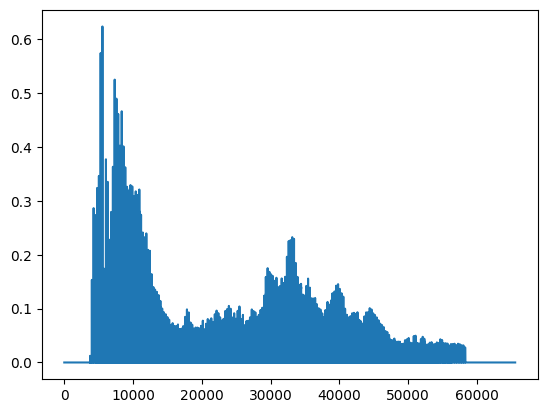

In [226]:

plt.plot(variance_mask.flatten())

In [227]:
torch.autograd.set_detect_anomaly(True)

batch_size = 64
num_epochs = 4000
early_stopping_treshold = 1e-7

attenu_fromEm_dataset = TensorDataset(attenu_fromEm_standard, attenu_fromEm_standard)

train_size = (int(0.7 * len(attenu_fromEm_standard)) // 4) * 4
val_size = int((len(attenu_fromEm_standard) - train_size)/2)
test_size = int(len(attenu_fromEm_standard) - train_size - val_size)

generator = torch.Generator().manual_seed(42)
attenu_fromEm_train_dataset, attenu_fromEm_val_dataset, attenu_fromEm_test_dataset = random_split(attenu_fromEm_dataset, [train_size, val_size, test_size], generator=generator)

attenu_fromEm_train_dataloader = DataLoader(attenu_fromEm_train_dataset, batch_size = batch_size, shuffle = 1)
attenu_fromEm_val_dataloader = DataLoader(attenu_fromEm_val_dataset, batch_size = batch_size, shuffle = 1)
attenu_fromEm_test_dataloader = DataLoader(attenu_fromEm_test_dataset, batch_size = batch_size, shuffle = 1)

model = Autoencoder(image_dimension = attenu_fromEm_standard.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()




epoch_loss = []
epoch_loss_val = []

# using linear regression to prevent overfitting
window_size = 100

reg = sklearn.linear_model.LinearRegression()
window = np.arange(window_size).reshape(-1, 1)

try:
    for epoch in range(num_epochs):
        start = torch.Event(enable_timing=True)
        end = torch.Event(enable_timing=True)

        start.record()

        model.train()
        running_loss = 0.0
        running_loss_val = 0.0
        for train_batch, _ in attenu_fromEm_train_dataloader:
            
            outputs = model.main(train_batch)
            loss = criterion(outputs, train_batch)
            #loss = flightpath_MSELoss(outputs, train_batch, radar_mask)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * train_batch.size(0)
        
        for val_batch, _ in attenu_fromEm_val_dataloader:
            outputs = model.main(val_batch)
            loss = criterion(outputs, val_batch)
            #loss = flightpath_MSELoss(outputs, val_batch, radar_mask)

            running_loss_val += loss.item() * val_batch.size(0)
        
        epoch_loss.append(running_loss / len(attenu_fromEm_train_dataloader.dataset))
        epoch_loss_val.append(running_loss_val / len(attenu_fromEm_val_dataloader.dataset))

        end.record()

        print(f"Epoch [{epoch + 1}/{num_epochs}], loss: {epoch_loss[epoch]:.4f}, validation loss: {epoch_loss_val[epoch]:.4f}, time elapsed = {start.elapsed_time(end)/1000:.2f} s")
        
        

        if epoch >= window.shape[0]:
            reg.fit(window, epoch_loss[-window_size:])
            epoch_loss_slope = reg.coef_
            print(f"Epoch loss slope: {epoch_loss_slope}")

            reg.fit(window, epoch_loss_val[-window_size:])
            epoch_loss_val_slope = reg.coef_
            print(f"Epoch validation loss slope: {epoch_loss_val_slope}")

            # if (np.abs(epoch_loss_slope) < early_stopping_treshold) or (np.abs(epoch_loss_val_slope) < early_stopping_treshold):
            #     print("Early stopping")
            #     break
        
    torch.save(model.state_dict(), f'autoencoder_{datetime.datetime.now()}.pth')
    np.savez(f'autoencoder_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)

except KeyboardInterrupt:
    torch.save(model.state_dict(), f'autoencoder_{datetime.datetime.now()}.pth')
    np.savez(f'autoencoder_{datetime.datetime.now()}_loss.npz',epoch_loss = epoch_loss, epoch_loss_val = epoch_loss_val)

Epoch [1/4000], loss: 0.0794, validation loss: 0.0580, time elapsed = 0.37 s
Epoch [2/4000], loss: 0.0548, validation loss: 0.0466, time elapsed = 0.37 s
Epoch [3/4000], loss: 0.0447, validation loss: 0.0408, time elapsed = 0.37 s
Epoch [4/4000], loss: 0.0398, validation loss: 0.0391, time elapsed = 0.36 s
Epoch [5/4000], loss: 0.0385, validation loss: 0.0388, time elapsed = 0.35 s
Epoch [6/4000], loss: 0.0381, validation loss: 0.0382, time elapsed = 0.36 s
Epoch [7/4000], loss: 0.0375, validation loss: 0.0374, time elapsed = 0.35 s
Epoch [8/4000], loss: 0.0366, validation loss: 0.0367, time elapsed = 0.35 s
Epoch [9/4000], loss: 0.0360, validation loss: 0.0361, time elapsed = 0.35 s
Epoch [10/4000], loss: 0.0354, validation loss: 0.0356, time elapsed = 0.35 s
Epoch [11/4000], loss: 0.0350, validation loss: 0.0352, time elapsed = 0.35 s
Epoch [12/4000], loss: 0.0346, validation loss: 0.0349, time elapsed = 0.35 s
Epoch [13/4000], loss: 0.0342, validation loss: 0.0346, time elapsed = 0.

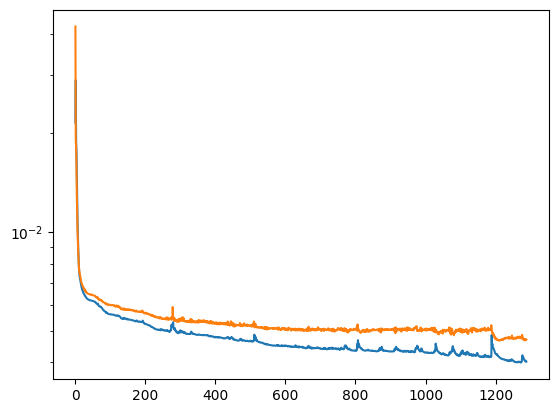

In [183]:
# loss_file = np.load("../testing/autoencoder_2026-06-25 15:51:15.363896_loss.npz")
# epoch_loss = loss_file['epoch_loss']
# epoch_loss_val = loss_file['epoch_loss_val']

plt.plot(epoch_loss)
plt.plot(epoch_loss_val)
plt.gca().set_yscale('log')

In [ ]:
reg = sklearn.linear_model.LinearRegression()
reg_coef_all = []
reg_coef_all_val = []

window_size = 200

for i in np.arange(window_size, epoch_loss_val.shape[0]-window_size):
    x = np.arange(epoch_loss_val[i:i+window_size].shape[0])
    
    reg.fit(x.reshape(-1, 1), epoch_loss[i:i+window_size])
    reg_coef_all.append(reg.coef_)

    reg.fit(x.reshape(-1, 1), epoch_loss_val[i:i+window_size])
    reg_coef_all_val.append(reg.coef_)

AttributeError: 'list' object has no attribute 'shape'

(-2e-05, 2e-05)

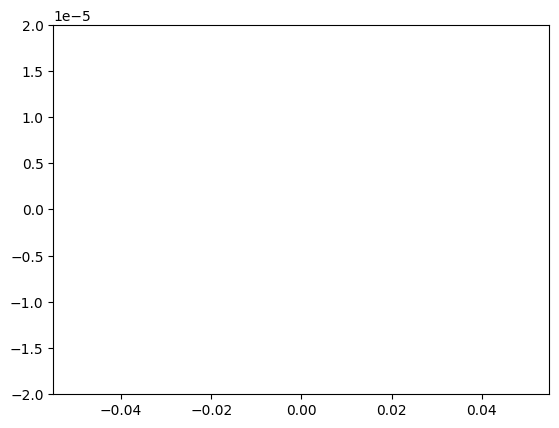

In [16]:
plt.plot(reg_coef_all)
#plt.plot(reg_coef_all_val)
plt.plot(np.ones(len(reg_coef_all)) * 1e-6)
plt.plot(np.ones(len(reg_coef_all)) * -1e-6)
plt.ylim((-2e-5, 2e-5))

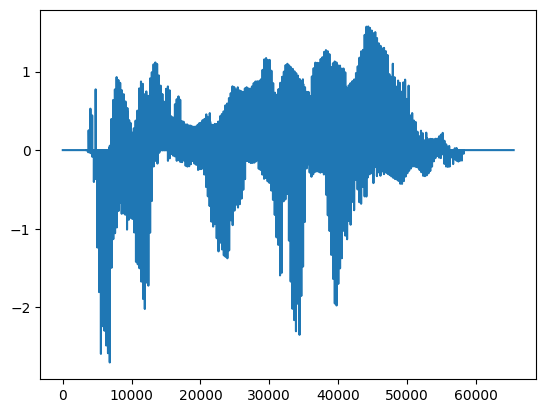

In [184]:
plt.plot((attenu_fromEm_train_dataset[0][0] - attenu_fromEm_train_dataset[10][0]).detach().numpy().flatten())

In [18]:
# state_dict = torch.load('../testing/autoencoder_2026-06-25 15:51:15.000658.pth')
# model = Autoencoder(image_dimension = attenu_fromEm_standard.shape[2], kernel_1_size = 3, kernel_2_size = 5)
# model.load_state_dict(state_dict)

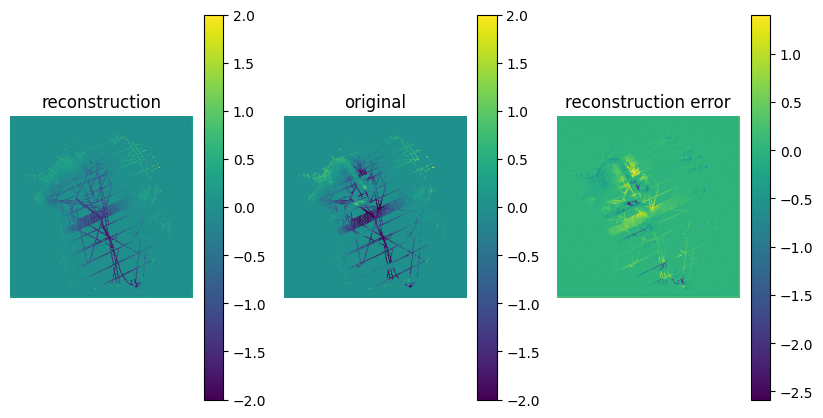

In [228]:
figs, axs = plt.subplots(1, 3, figsize = (10, 5))

idx = 10

vmin = -2
vmax = 2

im0 = axs[0].imshow(model.main(attenu_fromEm_train_dataset[idx][0]).detach().numpy()[0, 0, :, :], vmin = vmin, vmax = vmax)
axs[0].invert_yaxis()
axs[0].axis('off')
axs[0].set_title("reconstruction")
plt.colorbar(im0)

im1 = axs[1].imshow(attenu_fromEm_train_dataset[idx][0].detach().numpy()[0, :, :], vmin = vmin, vmax = vmax)
axs[1].invert_yaxis()
axs[1].axis('off')
axs[1].set_title("original")
plt.colorbar(im1)

im2 = axs[2].imshow((model.main(attenu_fromEm_train_dataset[idx][0]) - attenu_fromEm_train_dataset[idx][0]).detach().numpy()[0, 0, :, :])
axs[2].invert_yaxis()
axs[2].axis('off')
axs[2].set_title("reconstruction error")
plt.colorbar(im2)

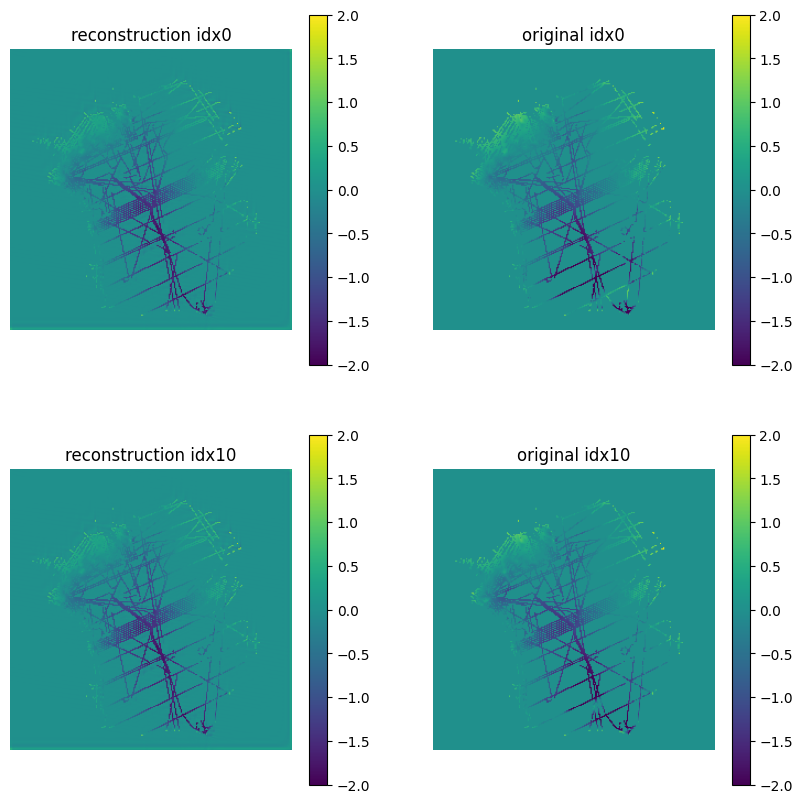

In [229]:
figs, axs = plt.subplots(2, 2, figsize = (10, 10))

idx = [0, 10]

reconstruct_0 = model.main(attenu_fromEm_test_dataset[idx[0]][0]).detach().numpy()[0, 0, :, :]
original_0 = attenu_fromEm_test_dataset[idx[0]][1].detach().numpy()[0, :, :]

reconstruct_1 = model.main(attenu_fromEm_test_dataset[idx[1]][0]).detach().numpy()[0, 0, :, :]
original_1 = attenu_fromEm_test_dataset[idx[1]][1].detach().numpy()[0, :, :]

im0 = axs[0, 0].imshow(reconstruct_0, vmin = -2, vmax = 2)
axs[0, 0].invert_yaxis()
axs[0, 0].axis('off')
axs[0, 0].set_title(f"reconstruction idx{idx[0]}")
plt.colorbar(im0)

im1 = axs[0, 1].imshow(original_0, vmin = -2, vmax = 2)
axs[0, 1].invert_yaxis()
axs[0, 1].axis('off')
axs[0, 1].set_title(f"original idx{idx[0]}")
plt.colorbar(im1)

im2 = axs[1, 0].imshow(reconstruct_1, vmin = -2, vmax = 2)
axs[1, 0].invert_yaxis()
axs[1, 0].axis('off')
axs[1, 0].set_title(f"reconstruction idx{idx[1]}")
plt.colorbar(im2)

im2 = axs[1, 1].imshow(original_1, vmin = -2, vmax = 2)
axs[1, 1].invert_yaxis()
axs[1, 1].axis('off')
axs[1, 1].set_title(f"original idx{idx[1]}")
plt.colorbar(im2)

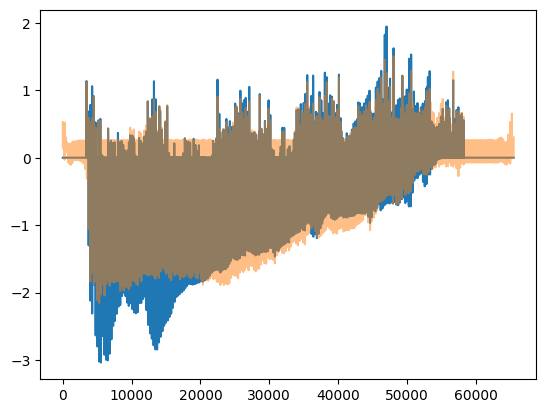

In [230]:
plt.plot(original_1.flatten())
plt.plot(reconstruct_1.flatten(), alpha = 0.5)

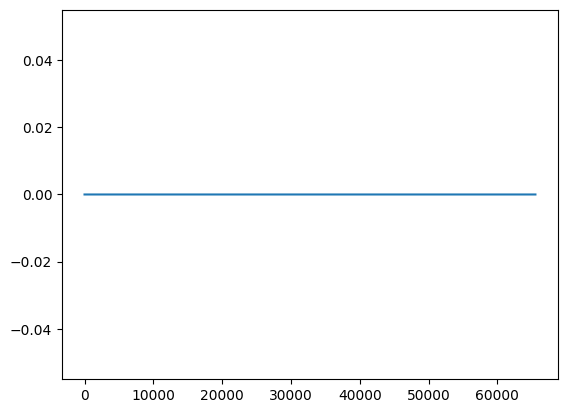

In [231]:
plt.plot((model.main(attenu_fromEm_test_dataset[0][0]) - model.main(attenu_fromEm_test_dataset[1][0])).detach().numpy().flatten())

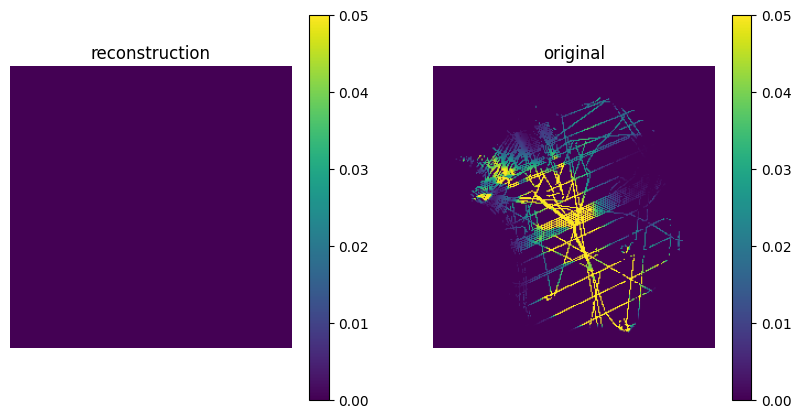

In [232]:
var_reconstruct = np.nanvar(model.main(attenu_fromEm_test_dataset[:][0]).detach().numpy(), axis = 0)[0, :, :]
var_original = np.nanvar(attenu_fromEm_test_dataset[:][0].detach().numpy(), axis = 0)[0, :, :]

figs, axs = plt.subplots(1, 2, figsize = (10, 5))

vmin = 0
vmax = 0.05

im0 = axs[0].imshow(var_reconstruct, vmin = vmin, vmax = vmax)
axs[0].invert_yaxis()
axs[0].axis('off')
axs[0].set_title("reconstruction")
plt.colorbar(im0)

im1 = axs[1].imshow(var_original, vmin = vmin, vmax = vmax)
axs[1].invert_yaxis()
axs[1].axis('off')
axs[1].set_title("original")
plt.colorbar(im1)

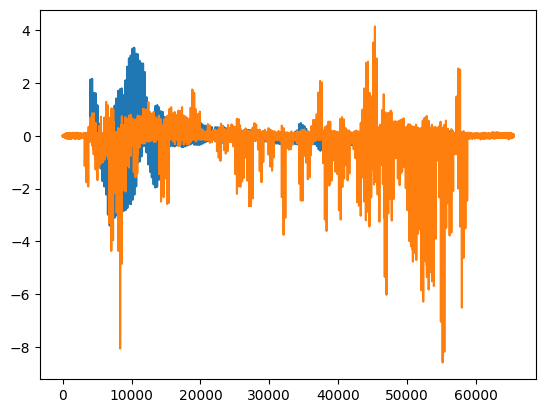

In [208]:
plt.plot(original_1.flatten() - original_0.flatten())
plt.plot(reconstruct_1.flatten() - reconstruct_0.flatten())


In [ ]:
# attenu_latent = model.encoder(attenu_fromEm_standard)

# torch.save(attenu_latent, 'attenu_latent.pt')
# torch.save(model.state_dict(), f'autoencoder_{datetime.datetime.now()}.pth')